# Visualizaciones: Análisis Morfosintáctico POS Tagging
## Reseñas Turísticas de Costa Rica
**Curso:** Minería de Textos · CUC

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import spacy
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Cargar corpus limpio
corpus = pd.read_csv("resenas_clean.csv")
nlp    = spacy.load('es_core_news_md')

print(f'Corpus cargado: {len(corpus)} reseñas')
corpus.head(3)

Corpus cargado: 1008 reseñas


,texto,calificacion,polaridad,tipo_lugar,fuente,fecha,texto_limpio
0,"Un lugar espectacular y, sin duda, una visita ...",3,neutral,parque,google_maps,06/06/2026 02:10:30,un lugar espectacular y sin duda una visita ob...
1,"El parque es espectacular, las 3 son porque es...",3,neutral,parque,google_maps,06/05/2026 21:24:50,el parque es espectacular las son porque esta ...
2,"Increíble!! Lleno de flora y fauna del país, c...",5,positivo,parque,google_maps,06/05/2026 03:38:27,increíble lleno de flora y fauna del país con ...


In [24]:
# ── Procesar POS con spaCy
corpus['spacy_doc'] = corpus['texto_limpio'].astype(str).apply(nlp)

def contar_pos(documentos):
    contador = Counter()
    for doc in documentos:
        for token in doc:
            if not token.is_space:
                contador[token.pos_] += 1
    return contador

pos_total    = contar_pos(corpus['spacy_doc'])
pos_positivo = contar_pos(corpus[corpus['polaridad'] == 'positivo']['spacy_doc'])
pos_negativo = contar_pos(corpus[corpus['polaridad'] == 'negativo']['spacy_doc'])

print('POS calculados ')

POS calculados 


---
## Gráfico 1 · Distribución POS del corpus completo

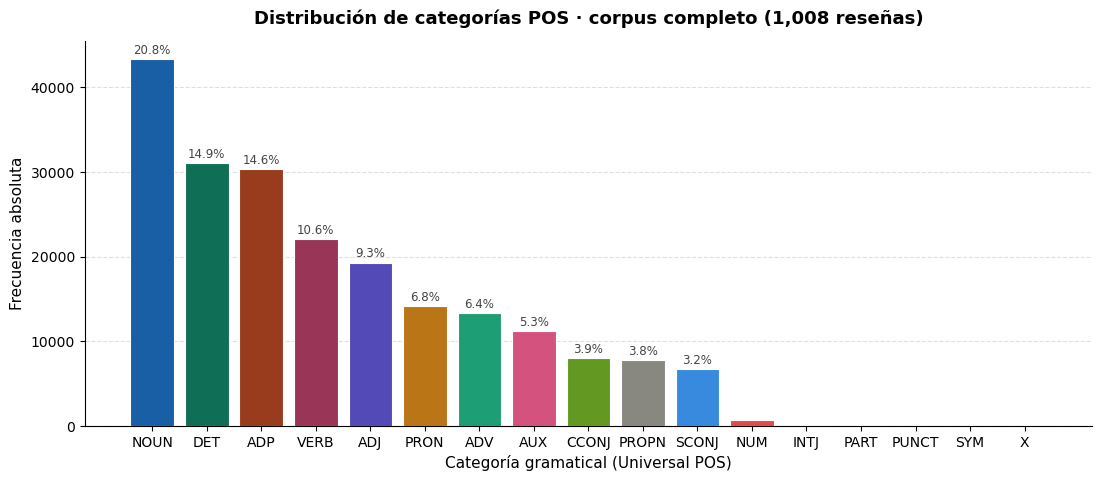

In [25]:
# Datos ordenados de mayor a menor
pos_df = pd.DataFrame(pos_total.most_common(), columns=['POS', 'cantidad'])
pos_df = pos_df[pos_df['POS'] != 'SPACE']
total  = pos_df['cantidad'].sum()
pos_df['porcentaje'] = (pos_df['cantidad'] / total * 100).round(2)

# Paleta de colores por categoría
colores = {
    'NOUN':'#185FA5','DET':'#0F6E56','ADP':'#993C1D',
    'VERB':'#993556','ADJ':'#534AB7','PRON':'#BA7517',
    'ADV':'#1D9E75','AUX':'#D4537E','CCONJ':'#639922',
    'PROPN':'#888780','SCONJ':'#378ADD','NUM':'#E24B4A',
    'INTJ':'#EF9F27','PART':'#5DCAA5','PUNCT':'#B4B2A9',
    'SYM':'#AFA9EC','X':'#F0997B'
}

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(
    pos_df['POS'],
    pos_df['cantidad'],
    color=[colores.get(p, '#888') for p in pos_df['POS']],
    edgecolor='white', linewidth=0.8
)

# Etiquetas de porcentaje sobre cada barra
for bar, pct in zip(bars, pos_df['porcentaje']):
    if pct >= 0.5:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=8.5, color='#444'
        )

ax.set_title('Distribución de categorías POS · corpus completo (1,008 reseñas)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Categoría gramatical (Universal POS)', fontsize=11)
ax.set_ylabel('Frecuencia absoluta', fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)



---
## Gráfico 2 · Positivas vs Negativas (comparación POS)

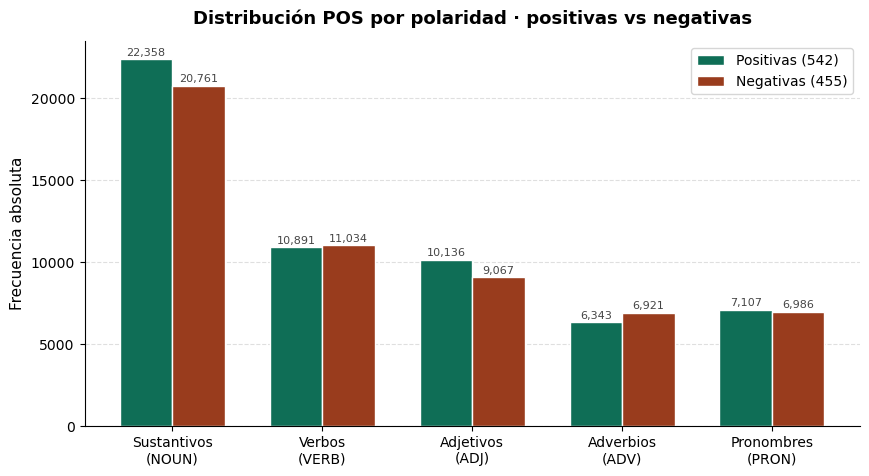

In [26]:
cats      = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON']
vals_pos  = [pos_positivo[c] for c in cats]
vals_neg  = [pos_negativo[c] for c in cats]
labels_es = ['Sustantivos\n(NOUN)', 'Verbos\n(VERB)', 'Adjetivos\n(ADJ)',
             'Adverbios\n(ADV)', 'Pronombres\n(PRON)']

x = np.arange(len(cats))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - w/2, vals_pos, w, label='Positivas (542)', color='#0F6E56', edgecolor='white')
b2 = ax.bar(x + w/2, vals_neg, w, label='Negativas (455)', color='#993C1D', edgecolor='white')

# Valores sobre las barras
for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8, color='#444'
    )

ax.set_title('Distribución POS por polaridad · positivas vs negativas',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(labels_es, fontsize=10)
ax.set_ylabel('Frecuencia absoluta', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)



---
## Gráfico 3 · Densidad de adjetivos por polaridad

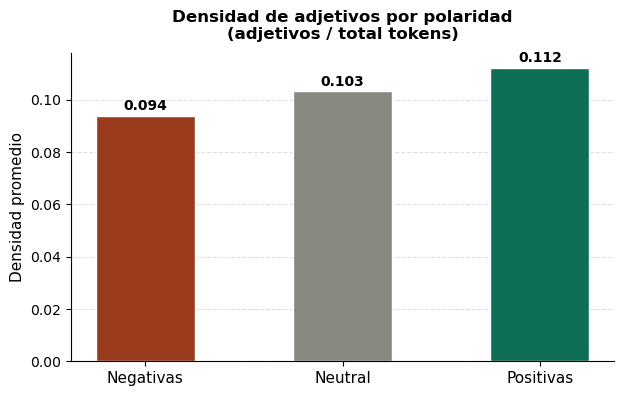

In [27]:
# Calcular adjetivos por reseña (normalizado por total de tokens)
def densidad_adj(doc):
    tokens = [t for t in doc if not t.is_space]
    if len(tokens) == 0:
        return 0
    adj = sum(1 for t in tokens if t.pos_ == 'ADJ')
    return adj / len(tokens)

corpus['densidad_adj'] = corpus['spacy_doc'].apply(densidad_adj)

densidad_por_pol = corpus.groupby('polaridad')['densidad_adj'].mean().reindex(
    ['negativo', 'neutral', 'positivo']
)

fig, ax = plt.subplots(figsize=(7, 4))

colores_pol = ['#993C1D', '#888780', '#0F6E56']
bars = ax.bar(densidad_por_pol.index, densidad_por_pol.values,
              color=colores_pol, edgecolor='white', width=0.5)

for bar, val in zip(bars, densidad_por_pol.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Densidad de adjetivos por polaridad\n(adjetivos / total tokens)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Densidad promedio', fontsize=11)
ax.set_xticklabels(['Negativas', 'Neutral', 'Positivas'], fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)



---
## Gráfico 4 · Longitud promedio por polaridad

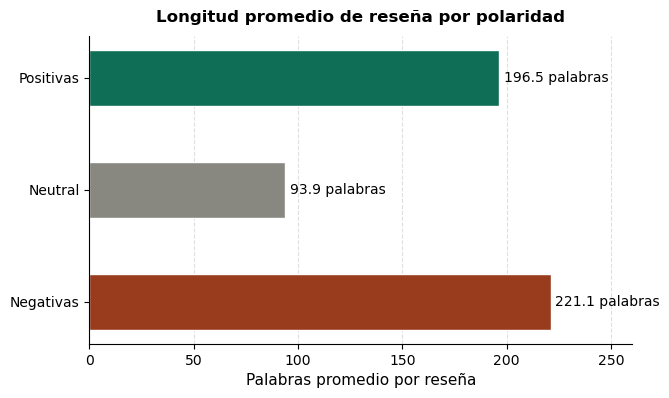

In [28]:
corpus['n_palabras'] = corpus['texto_limpio'].astype(str).apply(lambda x: len(x.split()))
longitud_pol = corpus.groupby('polaridad')['n_palabras'].mean().reindex(
    ['negativo', 'neutral', 'positivo']
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    ['Negativas', 'Neutral', 'Positivas'],
    longitud_pol.values,
    color=['#993C1D', '#888780', '#0F6E56'],
    edgecolor='white', height=0.5
)

for bar, val in zip(bars, longitud_pol.values):
    ax.text(
        bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f} palabras',
        va='center', fontsize=10
    )

ax.set_title('Longitud promedio de reseña por polaridad',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Palabras promedio por reseña', fontsize=11)
ax.set_xlim(0, 260)
ax.spines[['top','right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)



---
## Gráfico 5 · Distribución de calificaciones (pie)

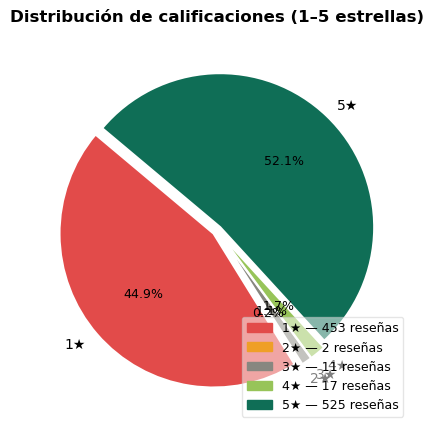

In [29]:
cal_counts = corpus['calificacion'].value_counts().sort_index()

colores_estrellas = ['#E24B4A','#EF9F27','#888780','#97C459','#0F6E56']
explode = [0.03] * len(cal_counts)

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    cal_counts.values,
    labels=[f'{i}★' for i in cal_counts.index],
    autopct='%1.1f%%',
    colors=colores_estrellas,
    explode=explode,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)

ax.set_title('Distribución de calificaciones (1–5 estrellas)',
             fontsize=12, fontweight='bold', pad=12)

# Leyenda con conteo
handles = [
    mpatches.Patch(color=c, label=f'{i}★ — {n:,} reseñas')
    for i, n, c in zip(cal_counts.index, cal_counts.values, colores_estrellas)
]
ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.5)



---
## Gráfico 6 · Ratio sustantivos/verbos y densidad léxica por polaridad

polaridad  ratio_N/V  densidad_léxica
 positivo      2.053           0.4669
 negativo      1.882           0.4749


Text(0.5, 1.02, 'Métricas morfológicas derivadas por polaridad')

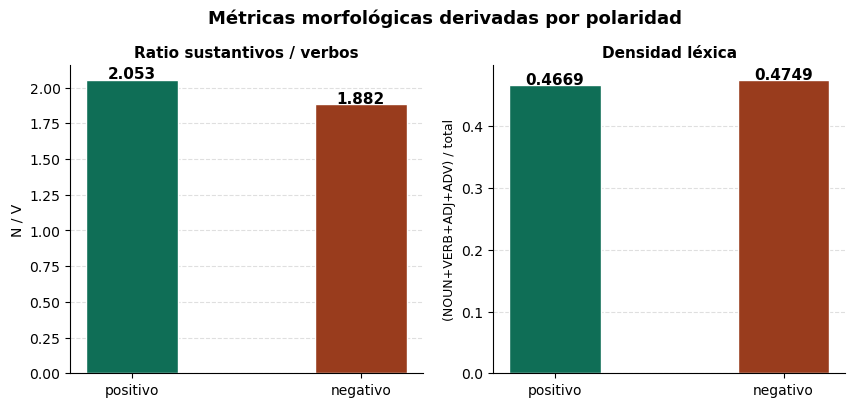

In [30]:
# Métricas por polaridad
metricas = []
for pol in ['positivo', 'negativo']:
    docs = corpus[corpus['polaridad'] == pol]['spacy_doc']
    cnt  = contar_pos(docs)
    total_tok = sum(cnt.values())
    ratio_nv  = cnt['NOUN'] / cnt['VERB'] if cnt['VERB'] > 0 else 0
    dens_lex  = (cnt['NOUN'] + cnt['VERB'] + cnt['ADJ'] + cnt['ADV']) / total_tok
    metricas.append({'polaridad': pol, 'ratio_N/V': round(ratio_nv, 3),
                     'densidad_léxica': round(dens_lex, 4)})

df_met = pd.DataFrame(metricas)
print(df_met.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel izquierdo: ratio N/V
c_pol = ['#0F6E56', '#993C1D']
axes[0].bar(df_met['polaridad'], df_met['ratio_N/V'],
            color=c_pol, edgecolor='white', width=0.4)
for i, val in enumerate(df_met['ratio_N/V']):
    axes[0].text(i, val + 0.01, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Ratio sustantivos / verbos', fontsize=11, fontweight='bold')
axes[0].set_ylabel('N / V', fontsize=10)
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# Panel derecho: densidad léxica
axes[1].bar(df_met['polaridad'], df_met['densidad_léxica'],
            color=c_pol, edgecolor='white', width=0.4)
for i, val in enumerate(df_met['densidad_léxica']):
    axes[1].text(i, val + 0.001, str(val), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Densidad léxica', fontsize=11, fontweight='bold')
axes[1].set_ylabel('(NOUN+VERB+ADJ+ADV) / total', fontsize=9)
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_axisbelow(True)

fig.suptitle('Métricas morfológicas derivadas por polaridad',
             fontsize=13, fontweight='bold', y=1.02)



---
## Gráfico 7 · Top 15 palabras más frecuentes (sin stopwords funcionales)

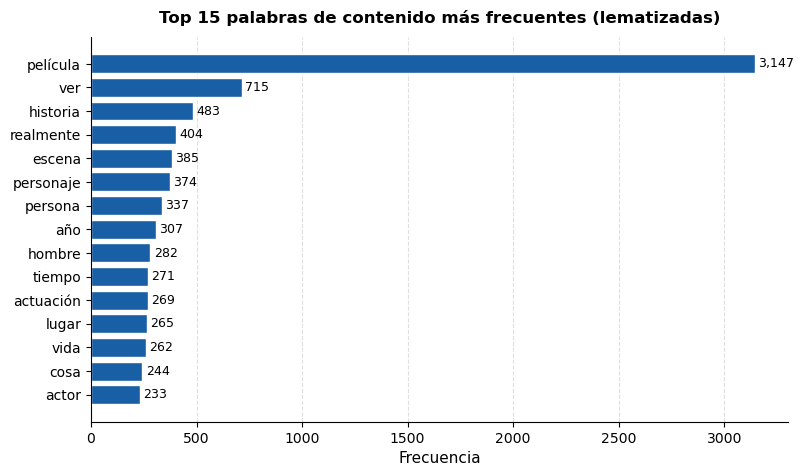

In [31]:
# Palabras de contenido (NOUN, ADJ, VERB, ADV) — las más informativas
palabras_contenido = []
for doc in corpus['spacy_doc']:
    for token in doc:
        if token.pos_ in ('NOUN', 'ADJ', 'VERB', 'ADV') and not token.is_stop:
            palabras_contenido.append(token.lemma_.lower())

top15 = pd.DataFrame(Counter(palabras_contenido).most_common(15),
                     columns=['palabra', 'frecuencia'])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top15['palabra'][::-1], top15['frecuencia'][::-1],
               color='#185FA5', edgecolor='white')

for bar, val in zip(bars, top15['frecuencia'][::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}', va='center', fontsize=9)

ax.set_title('Top 15 palabras de contenido más frecuentes (lematizadas)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)



In [1]:
from dash import Dash, dcc, html, Input, Output, ctx
import webbrowser
from threading import Timer

app = Dash(__name__)

figuras = {
    "btn1": fig1,
    "btn2": fig2,
    "btn3": fig3,
    "btn4": fig4,
    "btn5": fig5,
    "btn6": fig6,
    "btn7": fig7
}

app.layout = html.Div([
    html.H1(
        "Dashboard · POS Tagging · Reseñas CR",
        style={"textAlign": "center"}
    ),

    html.Div([
        html.Button("Distribución POS", id="btn1", n_clicks=0),
        html.Button("POS por polaridad", id="btn2", n_clicks=0),
        html.Button("Densidad adjetivos", id="btn3", n_clicks=0),
        html.Button("Longitud promedio", id="btn4", n_clicks=0),
        html.Button("Calificaciones", id="btn5", n_clicks=0),
        html.Button("Métricas morfológicas", id="btn6", n_clicks=0),
        html.Button("Top 15 palabras", id="btn7", n_clicks=0),
    ], style={
        "display": "flex",
        "flexWrap": "wrap",
        "gap": "10px",
        "justifyContent": "center",
        "marginBottom": "20px"
    }),

    dcc.Graph(
        id="grafico-principal",
        figure=fig1,
        config={
            "displayModeBar": True,
            "scrollZoom": True,
            "displaylogo": False
        }
    )
])

@app.callback(
    Output("grafico-principal", "figure"),
    [
        Input("btn1", "n_clicks"),
        Input("btn2", "n_clicks"),
        Input("btn3", "n_clicks"),
        Input("btn4", "n_clicks"),
        Input("btn5", "n_clicks"),
        Input("btn6", "n_clicks"),
        Input("btn7", "n_clicks"),
    ]
)
def cambiar_grafico(*args):

    if not ctx.triggered:
        return fig1

    boton = ctx.triggered_id

    return figuras[boton]

def abrir_navegador():
    webbrowser.open("http://127.0.0.1:8050/")

Timer(1, abrir_navegador).start()

app.run(debug=True, port=8050, use_reloader=False)

NameError: name 'fig1' is not defined